<a href="https://colab.research.google.com/github/Menelik33/nlp-slot-classification-encoder-model/blob/main/Deep_Learning_for_Text_Encoder_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Text - Encoder Models

## Data Preprocessing


In [ ]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from google.colab import drive

keras.utils.set_random_seed(42)

Upload the flight query datasets below

In [ ]:
drive.mount('/content/drive')
df_train = pd.read_csv('/content/drive/MyDrive/XPro/atis_train_data.csv')
df_test = pd.read_csv('/content/drive/MyDrive/XPro/atis_test_data.csv')

Mounted at /content/drive


data visualization

In [ ]:
pd.set_option('display.max_colwidth', -1)
df_small = pd.DataFrame(columns=['query','intent','slot filling'])
j = 0
for i in df_train.intent.unique():
  df_small.loc[j] = df_train[df_train.intent==i].iloc[0]
  j = j+1

df_small

<ipython-input-3-a33faa3ccad2>:1: FutureWarning: Passing a negative integer is deprecated in version 1.0 and will not be supported in future version. Instead, use None to not limit the column width.
  pd.set_option('display.max_colwidth', -1)


,query,intent,slot filling
0,i want to fly from boston at 838 am and arrive in denver at 1110 in the morning,flight,O O O O O B-fromloc.city_name O B-depart_time.time I-depart_time.time O O O B-toloc.city_name O B-arrive_time.time O O B-arrive_time.period_of_day
1,what is the arrival time in san francisco for the 755 am flight leaving washington,flight_time,O O O B-flight_time I-flight_time O B-fromloc.city_name I-fromloc.city_name O O B-depart_time.time I-depart_time.time O O B-fromloc.city_name
2,cheapest airfare from tacoma to orlando,airfare,B-cost_relative O O B-fromloc.city_name O B-toloc.city_name
3,what kind of aircraft is used on a flight from cleveland to dallas,aircraft,O O O O O O O O O O B-fromloc.city_name O B-toloc.city_name
4,what kind of ground transportation is available in denver,ground_service,O O O O O O O O B-city_name
5,what 's the airport at orlando,airport,O O O O O B-city_name
6,which airline serves denver pittsburgh and atlanta,airline,O O O B-fromloc.city_name B-fromloc.city_name O B-fromloc.city_name
7,how far is it from orlando airport to orlando,distance,O O O O O B-fromloc.airport_name I-fromloc.airport_name O B-toloc.city_name
8,what is fare code h,abbreviation,O O O O B-fare_basis_code
9,how much does the limousine service cost within pittsburgh,ground_fare,O O O O B-transport_type O O O B-city_name


intent counts

In [ ]:
df_train['intent'].value_counts()

flight                        3666
airfare                       423 
ground_service                255 
airline                       157 
abbreviation                  147 
aircraft                      81  
flight_time                   54  
quantity                      51  
flight+airfare                21  
airport                       20  
distance                      20  
city                          19  
ground_fare                   18  
capacity                      16  
flight_no                     12  
meal                          6   
restriction                   6   
airline+flight_no             2   
ground_service+ground_fare    1   
airfare+flight_time           1   
cheapest                      1   
aircraft+flight+flight_no     1   
Name: intent, dtype: int64

In [ ]:
query_data_train = df_train['query'].values
intent_data_train = df_train['intent'].values
slot_data_train = df_train['slot filling'].values

query_data_test = df_test['query'].values
intent_data_test = df_test['intent'].values
slot_data_test = df_test['slot filling'].values

In [ ]:
all the unique slots

In [ ]:
unique_slots = set()
for s in slot_data_train:
  unique_slots = unique_slots.union(set(s.split()))
unique_slots

{'B-aircraft_code',
 'B-airline_code',
 'B-airline_name',
 'B-airport_code',
 'B-airport_name',
 'B-arrive_date.date_relative',
 'B-arrive_date.day_name',
 'B-arrive_date.day_number',
 'B-arrive_date.month_name',
 'B-arrive_date.today_relative',
 'B-arrive_time.end_time',
 'B-arrive_time.period_mod',
 'B-arrive_time.period_of_day',
 'B-arrive_time.start_time',
 'B-arrive_time.time',
 'B-arrive_time.time_relative',
 'B-city_name',
 'B-class_type',
 'B-connect',
 'B-cost_relative',
 'B-day_name',
 'B-day_number',
 'B-days_code',
 'B-depart_date.date_relative',
 'B-depart_date.day_name',
 'B-depart_date.day_number',
 'B-depart_date.month_name',
 'B-depart_date.today_relative',
 'B-depart_date.year',
 'B-depart_time.end_time',
 'B-depart_time.period_mod',
 'B-depart_time.period_of_day',
 'B-depart_time.start_time',
 'B-depart_time.time',
 'B-depart_time.time_relative',
 'B-economy',
 'B-fare_amount',
 'B-fare_basis_code',
 'B-flight_days',
 'B-flight_mod',
 'B-flight_number',
 'B-flight_st

In [ ]:
len(unique_slots)

123

**123 slot categories!!**

## Intent Prediction Model


In [ ]:
max_tokens = 10000
text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="multi_hot",
    ngrams=2
)
text_vectorization.adapt(query_data_train)


In [ ]:
text_vectorization.vocabulary_size()

6864

In [ ]:
text_vectorization.get_vocabulary()[:20]

['[UNK]',
 'to',
 'from',
 'flights',
 'the',
 'flights from',
 'on',
 'what',
 'me',
 'flight',
 'boston',
 'show',
 'san',
 'i',
 'denver',
 'show me',
 'a',
 'san francisco',
 'francisco',
 'in']

In [ ]:
query_data_train[:5]

array([' i want to fly from boston at 838 am and arrive in denver at 1110 in the morning ',
       ' what flights are available from pittsburgh to baltimore on thursday morning ',
       ' what is the arrival time in san francisco for the 755 am flight leaving washington ',
       ' cheapest airfare from tacoma to orlando ',
       ' round trip fares from pittsburgh to philadelphia under 1000 dollars '],
      dtype=object)

In [ ]:
intent_data_train[:5]

array(['flight', 'flight', 'flight_time', 'airfare', 'airfare'],
      dtype=object)

In [ ]:
input_vocab = text_vectorization.vocabulary_size()

query_data_train_vec = text_vectorization(query_data_train)
query_data_test_vec = text_vectorization(query_data_test)



In [ ]:
query_data_train_vec.shape

TensorShape([4978, 6864])

In [ ]:
query_data_train_vec[0]

<tf.Tensor: shape=(6864,), dtype=float32, numpy=array([0., 1., 1., ..., 0., 0., 0.], dtype=float32)>

In [ ]:
text_vectorization_intent = keras.layers.TextVectorization()
text_vectorization_intent.adapt(intent_data_train)

n_intents = text_vectorization_intent.vocabulary_size()

intent_data_train_sparse = text_vectorization_intent(intent_data_train)
intent_data_test_sparse = text_vectorization_intent(intent_data_test)

In [ ]:
n_intents

24

In [ ]:
intent_data_train_sparse.shape

TensorShape([4978, 1])

In [ ]:
intent_data_train_sparse[:5]

<tf.Tensor: shape=(5, 1), dtype=int64, numpy=
array([[2],
       [2],
       [8],
       [3],
       [3]])>

Intent classification model

In [ ]:
units = 64

inputs = keras.Input(shape=(input_vocab, ))
x = keras.layers.Dense(units=units)(inputs)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(n_intents, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 6864)]            0         
                                                                 
 dense (Dense)               (None, 64)                439360    
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 24)                1560      
                                                                 
Total params: 440,920
Trainable params: 440,920
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["sparse_categorical_accuracy"])

In [ ]:
model.fit(x=query_data_train_vec,
          y=intent_data_train_sparse,
          epochs=20)

Epoch 1/20
156/156 [==============================] - 5s 3ms/step - loss: 1.0438 - sparse_categorical_accuracy: 0.7883
Epoch 2/20
156/156 [==============================] - 0s 3ms/step - loss: 0.3843 - sparse_categorical_accuracy: 0.9142
Epoch 3/20
156/156 [==============================] - 0s 3ms/step - loss: 0.2100 - sparse_categorical_accuracy: 0.9546
Epoch 4/20
156/156 [==============================] - 0s 3ms/step - loss: 0.1223 - sparse_categorical_accuracy: 0.9761
Epoch 5/20
156/156 [==============================] - 0s 3ms/step - loss: 0.0771 - sparse_categorical_accuracy: 0.9890
Epoch 6/20
156/156 [==============================] - 0s 3ms/step - loss: 0.0540 - sparse_categorical_accuracy: 0.9928
Epoch 7/20
156/156 [==============================] - 0s 3ms/step - loss: 0.0382 - sparse_categorical_accuracy: 0.9948
Epoch 8/20
156/156 [==============================] - 0s 3ms/step - loss: 0.0273 - sparse_categorical_accuracy: 0.9972
Epoch 9/20
156/156 [============================

In [ ]:
model.evaluate(x=query_data_test_vec, y=intent_data_test_sparse)

28/28 [==============================] - 0s 3ms/step - loss: 0.3979 - sparse_categorical_accuracy: 0.9362


[0.3979095220565796, 0.936170220375061]

In [ ]:
df_test['intent'].value_counts() / df_test.shape[0]

flight               0.707727
airfare              0.053751
airline              0.042553
ground_service       0.040314
abbreviation         0.036954
capacity             0.023516
airport              0.020157
flight+airfare       0.013438
distance             0.011198
aircraft             0.010078
flight_no            0.008959
ground_fare          0.007839
city                 0.006719
meal                 0.006719
quantity             0.003359
day_name             0.002240
flight_time          0.001120
airfare+flight       0.001120
flight+airline       0.001120
flight_no+airline    0.001120
Name: intent, dtype: float64

## Word-to-Slot Classification Model

create 3 arrays: 2 to concantenate in the input and the slots at the output

In [ ]:
def transform_data_sentence(data):
  new_data = []
  for d in data:
    words = d.split()
    for w in words:
      new_data.append([w, d])
  words_train = [d[0] for d in new_data]
  sentence_train = [d[1] for d in new_data]
  return np.array(words_train), np.array(sentence_train)

def transform_data_slot(data):
  out = []
  for d in data:
    out += d.split()
  return np.array(out)

In [ ]:
words_train, query_train = transform_data_sentence(query_data_train)
words_test, query_test = transform_data_sentence(query_data_test)

In [ ]:
query_data_train[:2]

array([' i want to fly from boston at 838 am and arrive in denver at 1110 in the morning ',
       ' what flights are available from pittsburgh to baltimore on thursday morning '],
      dtype=object)

In [ ]:
query_train[:20]

array([' i want to fly from boston at 838 am and arrive in denver at 1110 in the morning ',
       ' i want to fly from boston at 838 am and arrive in denver at 1110 in the morning ',
       ' i want to fly from boston at 838 am and arrive in denver at 1110 in the morning ',
       ' i want to fly from boston at 838 am and arrive in denver at 1110 in the morning ',
       ' i want to fly from boston at 838 am and arrive in denver at 1110 in the morning ',
       ' i want to fly from boston at 838 am and arrive in denver at 1110 in the morning ',
       ' i want to fly from boston at 838 am and arrive in denver at 1110 in the morning ',
       ' i want to fly from boston at 838 am and arrive in denver at 1110 in the morning ',
       ' i want to fly from boston at 838 am and arrive in denver at 1110 in the morning ',
       ' i want to fly from boston at 838 am and arrive in denver at 1110 in the morning ',
       ' i want to fly from boston at 838 am and arrive in denver at 1110 in the

In [ ]:
words_train[:20]

array(['i', 'want', 'to', 'fly', 'from', 'boston', 'at', '838', 'am',
       'and', 'arrive', 'in', 'denver', 'at', '1110', 'in', 'the',
       'morning', 'what', 'flights'], dtype='<U16')

In [ ]:
slots_text_train = transform_data_slot(slot_data_train)
slots_text_test = transform_data_slot(slot_data_test)

In [ ]:
slot_data_train[0]

' O O O O O B-fromloc.city_name O B-depart_time.time I-depart_time.time O O O B-toloc.city_name O B-arrive_time.time O O B-arrive_time.period_of_day '

In [ ]:
slots_text_train[:20]

array(['O', 'O', 'O', 'O', 'O', 'B-fromloc.city_name', 'O',
       'B-depart_time.time', 'I-depart_time.time', 'O', 'O', 'O',
       'B-toloc.city_name', 'O', 'B-arrive_time.time', 'O', 'O',
       'B-arrive_time.period_of_day', 'O', 'O'], dtype='<U28')


The 3 text vectorizations
* for the sentence array: default standardization + bigrams + multi-hot encoding
* for the individual words: default standardization + unigrams + one-hot encoding
* for the slots: NO standardization + unigrams + int

In [ ]:
max_tokens = 10000
text_vectorization_query = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="multi_hot",
    ngrams=2
)
text_vectorization_query.adapt(query_train)
query_vocab_size = text_vectorization_query.vocabulary_size()

In [ ]:
text_vectorization_word = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="multi_hot",
    ngrams=1
)
text_vectorization_word.adapt(words_train)
word_vocab_size = text_vectorization_word.vocabulary_size()


In [ ]:
text_vectorization_slots = keras.layers.TextVectorization(
    standardize=None
)
text_vectorization_slots.adapt(slots_text_train)
slots_vocab_size = text_vectorization_slots.vocabulary_size()


The three text vectorization layers are ready and "populated" and we can now run the data through them.

In [ ]:
query_train_vec = text_vectorization_query(query_train)
words_train_vec = text_vectorization_word(words_train)
slots_train = text_vectorization_slots(slots_text_train)

query_test_vec = text_vectorization_query(query_test)
words_test_vec = text_vectorization_word(words_test)
slots_test = text_vectorization_slots(slots_text_test)


word to slot classification model

In [ ]:
units = 128
epochs = 10

input_query = keras.Input(shape=(query_vocab_size, ))
input_word = keras.Input(shape=(word_vocab_size, ))
x = keras.layers.Concatenate(axis=1)([input_query, input_word])
x = keras.layers.Dense(units=units)(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(slots_vocab_size, activation="softmax")(x)

model = keras.Model([input_query, input_word], outputs)
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 6864)]       0           []                               
                                                                                                  
 input_3 (InputLayer)           [(None, 887)]        0           []                               
                                                                                                  
 concatenate (Concatenate)      (None, 7751)         0           ['input_2[0][0]',                
                                                                  'input_3[0][0]']                
                                                                                                  
 dense_2 (Dense)                (None, 128)          992256      ['concatenate[0][0]']      

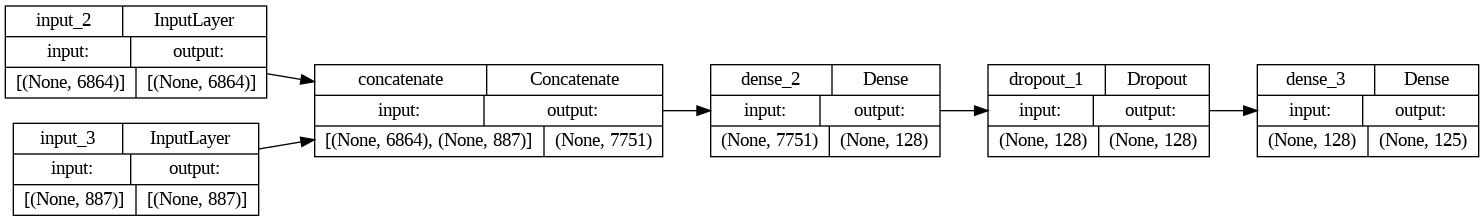

In [ ]:
keras.utils.plot_model(model, show_shapes=True, rankdir='LR')

In [ ]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["sparse_categorical_accuracy"])


In [ ]:
model.fit(x=[query_train_vec, words_train_vec],
          y=slots_train,
          epochs=epochs
          )

Epoch 1/10
1769/1769 [==============================] - 7s 4ms/step - loss: 0.8987 - sparse_categorical_accuracy: 0.7706
Epoch 2/10
1769/1769 [==============================] - 6s 3ms/step - loss: 0.3182 - sparse_categorical_accuracy: 0.8832
Epoch 3/10
1769/1769 [==============================] - 6s 3ms/step - loss: 0.2361 - sparse_categorical_accuracy: 0.9024
Epoch 4/10
1769/1769 [==============================] - 6s 3ms/step - loss: 0.2116 - sparse_categorical_accuracy: 0.9103
Epoch 5/10
1769/1769 [==============================] - 6s 3ms/step - loss: 0.1920 - sparse_categorical_accuracy: 0.9147
Epoch 6/10
1769/1769 [==============================] - 7s 4ms/step - loss: 0.1821 - sparse_categorical_accuracy: 0.9173
Epoch 7/10
1769/1769 [==============================] - 5s 3ms/step - loss: 0.1783 - sparse_categorical_accuracy: 0.9187
Epoch 8/10
1769/1769 [==============================] - 7s 4ms/step - loss: 0.1708 - sparse_categorical_accuracy: 0.9222
Epoch 9/10
1769/1769 [==========

In [ ]:
model.evaluate(x=[query_test_vec, words_test_vec], y=slots_test)

288/288 [==============================] - 1s 2ms/step - loss: 0.3235 - sparse_categorical_accuracy: 0.8931


[0.3234550952911377, 0.8931289315223694]

In [ ]:
from sklearn.metrics import accuracy_score

predicted = np.argmax(model.predict([query_test_vec, words_test_vec]), axis=-1)
actual = np.array([s[0] for s in slots_test])

non_slot_token = text_vectorization_slots(['O']).numpy()[0, 0]
acc = accuracy_score(actual, predicted)
acc_slots = accuracy_score(actual[actual != non_slot_token],
                           predicted[actual != non_slot_token])



print(f'Accuracy = {acc:.3f}')
print(f'Accuracy on slots = {acc_slots:.3f}')

288/288 [==============================] - 1s 3ms/step
Accuracy = 0.893
Accuracy on slots = 0.738


some examples below.

In [ ]:
def predict_slots_query(query):
  words = text_vectorization_word(query.split())
  sentence = text_vectorization_query([query for i in words])

  prediction = np.argmax(model.predict([np.array(sentence), np.array(words)]), axis=-1)

  inverse_vocab = dict(enumerate(text_vectorization_slots.get_vocabulary()))
  decoded_prediction = " ".join(inverse_vocab[int(i)] for i in prediction)
  return decoded_prediction

examples = [
            'from los angeles',
            'to los angeles',
            'from boston',
            'to boston',
            'cheapest flight from boston to los angeles tomorrow',
            'what is the airport at orlando',
            'what are the air restrictions on flights from pittsburgh to atlanta for the airfare of 416 dollars',
            'from boston to santiago'
]

for e in examples:
  print(e)
  print(predict_slots_query(e))
  print()

from los angeles
1/1 [==============================] - 0s 20ms/step
O B-toloc.city_name I-toloc.city_name

to los angeles
1/1 [==============================] - 0s 20ms/step
O B-toloc.city_name I-toloc.city_name

from boston
1/1 [==============================] - 0s 19ms/step
O B-fromloc.city_name

to boston
1/1 [==============================] - 0s 21ms/step
O B-fromloc.city_name

cheapest flight from boston to los angeles tomorrow
1/1 [==============================] - 0s 18ms/step
B-cost_relative O O B-fromloc.city_name O B-toloc.city_name I-toloc.city_name B-depart_date.today_relative

what is the airport at orlando
1/1 [==============================] - 0s 23ms/step
O O O O O B-city_name

what are the air restrictions on flights from pittsburgh to atlanta for the airfare of 416 dollars
1/1 [==============================] - 0s 24ms/step
O O O O O O O O B-fromloc.city_name O B-fromloc.city_name O O O O B-fare_amount I-fare_amount

from boston to santiago
1/1 [=====================

In [ ]:
predict_slots_query("i want to fly from New York to Los Angeles tomorrow afternoon")

1/1 [==============================] - 0s 23ms/step


'O O O O O B-fromloc.city_name I-fromloc.city_name O B-toloc.city_name I-toloc.city_name B-depart_date.today_relative B-depart_time.period_of_day'

In [ ]:
predict_slots_query("YOUR query here!")

1/1 [==============================] - 0s 21ms/step


'O O O'